Saving archive (2).zip to archive (2) (9).zip
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Volume  2000 non-null   float64
 1   Weight  2000 non-null   float64
 2   CO2     2000 non-null   float64
dtypes: float64(3)
memory usage: 47.0 KB
          Volume    Weight       CO2
Volume  1.000000  0.905403  0.909879
Weight  0.905403  1.000000  0.869412
CO2     0.909879  0.869412  1.000000


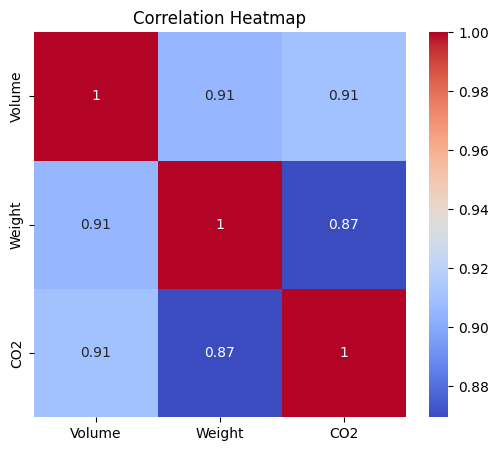

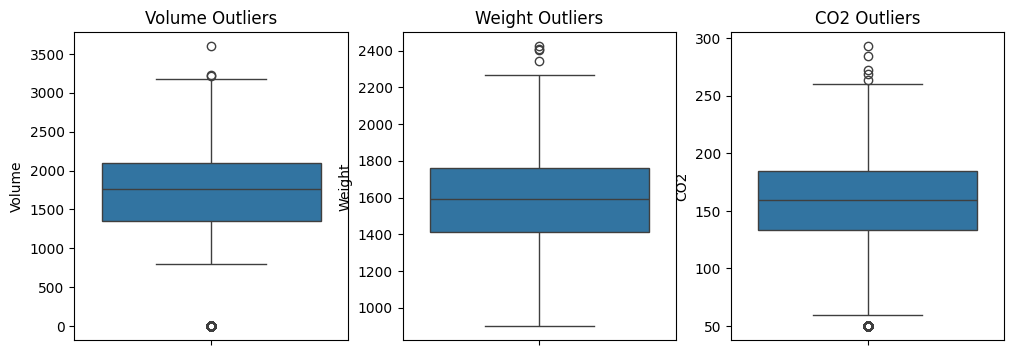

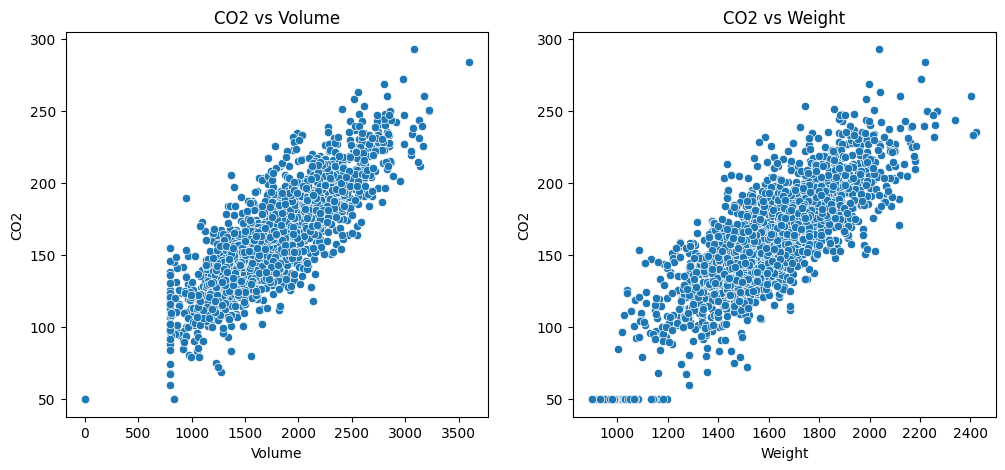

Weights: [0.04656695 0.0372453 ]
Intercept: 19.3961353455511


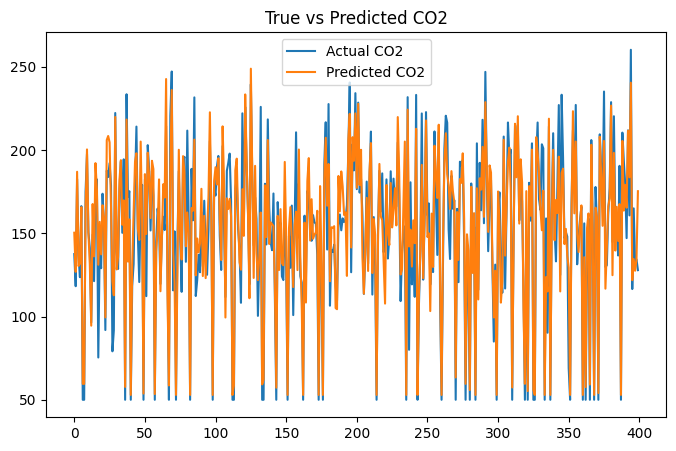

Mean Absolute Error: 13.043662655343564
Mean Squared Error: 300.41437526122735
Root Mean Squared Error: 17.332465931344778


In [ ]:
from google.colab import files
files.upload()
from sklearn.metrics import mean_absolute_error, mean_squared_error

import zipfile

zip_path = "archive (2) (3).zip"   # 👈 updated name

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    # print(zip_ref.namelist())   # VERY IMPORTANT
    zip_ref.extractall("data")
df = pd.read_csv("data/vehicle_co2_dataset.csv")

# (a)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("data/vehicle_co2_dataset.csv")

# Select required features
df = df[['engine_cc','vehicle_weight','co2_g_km']]

# Rename columns to match experiment statement
df.columns = ['Volume','Weight','CO2']

# Display data
df.head()
# Structure of dataset
df.info()
df.describe()

# (b)
corr = df.corr()
print(corr)

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
# (c)
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.boxplot(y=df['Volume'])
plt.title("Volume Outliers")

plt.subplot(1,3,2)
sns.boxplot(y=df['Weight'])
plt.title("Weight Outliers")

plt.subplot(1,3,3)
sns.boxplot(y=df['CO2'])
plt.title("CO2 Outliers")

plt.show()

# (d)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(x='Volume', y='CO2', data=df)
plt.title("CO2 vs Volume")

plt.subplot(1,2,2)
sns.scatterplot(x='Weight', y='CO2', data=df)
plt.title("CO2 vs Weight")

plt.show()


# (e)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['Volume','Weight']]
y = df['CO2']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

# (f)
# Coefficients (weights)
print("Weights:", model.coef_)

# Intercept
print("Intercept:", model.intercept_)

# Predictions
y_pred = model.predict(X_test)

# Line chart
plt.figure(figsize=(8,5))
plt.plot(y_test.values, label="Actual CO2")
plt.plot(y_pred, label="Predicted CO2")
plt.legend()
plt.title("True vs Predicted CO2")
plt.show()

# (g)from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)



